In [1]:
# Mounting the drive

from google.colab import drive

drive.mount('/content/drive')

print("Drive successfully mounted")

Mounted at /content/drive
Drive successfully mounted


In [2]:
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [13]:
feature_path = "/content/drive/MyDrive/AI_Healthcare_Diagnosis_system/feature_dataset.xlsx"

df = pd.read_excel(feature_path)

df.head()
df.shape

(134, 402)

In [14]:
# Separating Feature and Target
X = df.drop("Disease", axis=1)

y = df["Disease"]

y.head()

,Disease
0,UMLS:C0001175_acquired immuno-deficiency syndr...
1,UMLS:C0001418_adenocarcinoma
2,UMLS:C0001511_adhesion
3,UMLS:C0001973_chronic alcoholic intoxication
4,UMLS:C0002395_Alzheimer's disease


In [15]:
print("Feature shape", X.shape)
print("Target shape", y.shape)

Feature shape (134, 401)
Target shape (134,)


In [16]:
# Encoding disease label

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [17]:
# Splitting data into Train and Test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# Why random_state=42?
# It ensures the split is reproducible

In [18]:
# Verifying
print("Training Samples:", X_train.shape)

print("Testing Samples:", X_test.shape)

Training Samples: (107, 401)
Testing Samples: (27, 401)


In [19]:
# Model Creation
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [20]:
model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [22]:
# Making Predictions

y_pred = model.predict(X_test)

In [23]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.0


In [24]:
print(df["Disease"].value_counts())

Disease
UMLS:C0001175_acquired immuno-deficiency syndrome^UMLS:C0019682_HIV^UMLS:C0019693_hiv infections    1
UMLS:C0001418_adenocarcinoma                                                                        1
UMLS:C0001511_adhesion                                                                              1
UMLS:C0001973_chronic alcoholic intoxication                                                        1
UMLS:C0002395_Alzheimer's disease                                                                   1
                                                                                                   ..
UMLS:C1258215_ileus                                                                                 1
UMLS:C1456784_paranoia                                                                              1
UMLS:C1510475_diverticulosis                                                                        1
UMLS:C1565489_insufficiency renal                                         

In [25]:
print(df["Disease"].value_counts().describe())

count    134.0
mean       1.0
std        0.0
min        1.0
25%        1.0
50%        1.0
75%        1.0
max        1.0
Name: count, dtype: float64


In [26]:
print(df.shape)

(134, 402)


In [29]:
print(classification_report(y_test, y_pred, zero_division = 0))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       1.0
           7       0.00      0.00      0.00       0.0
          10       0.00      0.00      0.00       1.0
          12       0.00      0.00      0.00       1.0
          16       0.00      0.00      0.00       1.0
          18       0.00      0.00      0.00       1.0
          19       0.00      0.00      0.00       1.0
          25       0.00      0.00      0.00       0.0
          26       0.00      0.00      0.00       1.0
          27       0.00      0.00      0.00       1.0
          29       0.00      0.00      0.00       0.0
          31       0.00      0.00      0.00       1.0
          38       0.00      0.00      0.00       0.0
          39       0.00      0.00      0.00       0.0
          40       0.00      0.00      0.00       1.0
          41       0.00      0.00      0.00       0.0
          42       0.00    

In [30]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


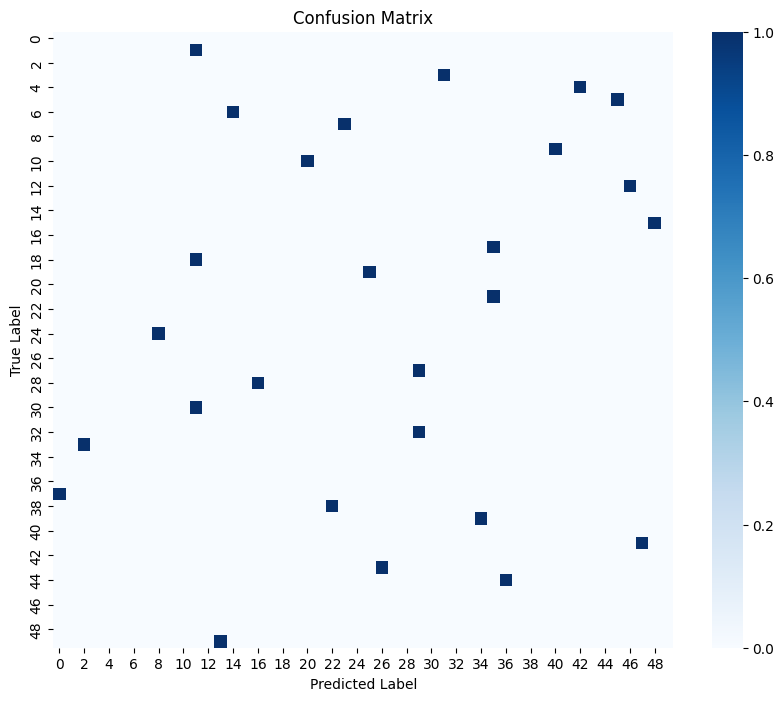

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(cm, annot=False, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [34]:
print("Actual Labels:")
print(y_test)

Actual Labels:
[127  66 104  19  42  60  12 109 100 101  44  40  27  47  73  31  83   4
  64  97  84  26  16  18  10 110  45]


In [35]:
print("Predicted Labels:")
print(y_pred)

Predicted Labels:
[ 38  41 119  54  87  25 107  63  49  85  29 122  46  87  29 118  71  29
  71   0   7 103 112  39  74  90  61]


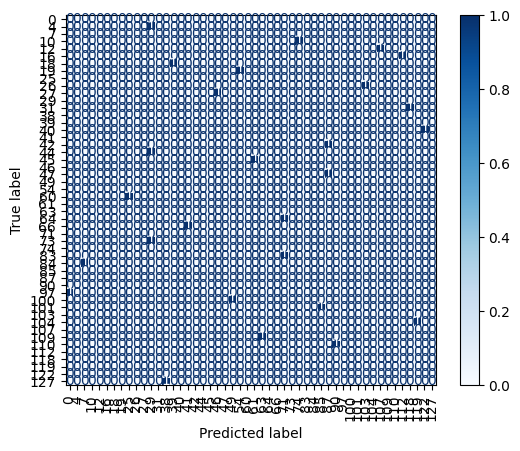

<Figure size 5000x5000 with 0 Axes>

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=90
)

plt.figure(figsize=(50,50))
plt.show()

In [44]:
cm = confusion_matrix(y_test, y_pred)

print("Shape:", cm.shape)
print(cm)

Shape: (50, 50)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [45]:
import numpy as np

print("Unique Actual Labels :", np.unique(y_test))
print("Unique Predicted Labels :", np.unique(y_pred))

Unique Actual Labels : [  4  10  12  16  18  19  26  27  31  40  42  44  45  47  60  64  66  73
  83  84  97 100 101 104 109 110 127]
Unique Predicted Labels : [  0   7  25  29  38  39  41  46  49  54  61  63  71  74  85  87  90 103
 107 112 118 119 122]


As we can see here that our model is giving the accuracy level as 0 also we are getting 0 for all values of confusion matrix
SO what is the insights we are getting :
1. We have the Dataset that having 1 disease per row hence the accuracy we are getting as

2. There is no problem with the code we have to change our strategy this dataset is not suitable for supervised learning model and we cannot go furthure with random forest
Conclusion:
We are going furthure with Building the AI Symptom Similarity Engine
  This will become the core intelligence behind the Healthcare Diagnosis Assistant, and it will work naturally with this dataset.